# Soch Probability & Statistics Analysis

This notebook documents the Probability & Statistics part of the **Soch** semester project using the real student mobile-phone survey dataset.

Each major section follows the same academic structure:

- **Concept**
- **Formula**
- **Python code**
- **Output / chart**
- **Interpretation**

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_dataset
from src.export_artifacts import create_artifacts
from src.ml_models import train_models
from src.preprocessing import (
    ADDICTION_SCORE_COMPONENTS,
    MODEL_FEATURE_SPECS,
    prepare_survey_dataset,
    serialize_preprocessing_config,
)
from src.stats_analysis import (
    build_frequency_table,
    clt_simulation,
    descriptive_statistics,
    histogram_frame,
    probability_summary,
    random_variable_summary,
)

sns.set_theme(style="whitegrid", palette="crest")
load_result = load_raw_dataset()
prepared = prepare_survey_dataset(load_result)
cleaned_df = prepared.cleaned_df.copy()
model_df = prepared.model_df.copy()
model_results = train_models(prepared)
preprocessing_config = serialize_preprocessing_config(prepared)

## 1. Project Introduction

**Concept**  
The project studies student mobile-phone behavior and turns the responses into a dataset that can be used for descriptive statistics, probability, sampling, and regression-based educational prediction.

**Formula**  
Statistics in this notebook are based on standard population measures:

\[
\mu = \frac{\sum x_i}{n}
\qquad
\sigma^2 = \frac{\sum (x_i - \mu)^2}{n}
\]

**Python code / Output / Interpretation**  
The next cells load the dataset, clean it, and summarize the usable sample.

## 2. Dataset Overview

**Concept**  
Before calculating statistics, we inspect where the dataset came from, how many rows it contains, and how many rows remain after cleaning.

**Formula**  
Sample size:

\[
n = \text{number of valid survey responses}
\]

In [2]:
overview = pd.Series(
    {
        "Dataset source": load_result.source,
        "Source type": load_result.source_type,
        "Raw rows": prepared.metadata["raw_row_count"],
        "Clean rows": prepared.metadata["clean_row_count"],
        "Model rows": prepared.metadata["model_row_count"],
        "Malformed rows removed": prepared.metadata["malformed_row_count"],
    }
)
display(overview.to_frame(name="value"))
cleaned_df.head()

,value
Dataset source,/home/farhann-saleem/Desktop/github/university...
Source type,csv
Raw rows,52
Clean rows,51
Model rows,51
Malformed rows removed,1


,response_id,source_row_number,answered_count,is_malformed,timestamp,timestamp_raw,age_group,gender,education_level,main_purpose,...,reduction_attempts,reduction_attempts_code,addiction_score,score_weight_coverage,score_band,risk_binary,risk_label,row_notes,model_feature_missing_count,score_component_count
0,R001,2,23,False,2026-04-10 12:10:47,10/04/2026 12:10:47,18-21,Female,University student,Social media,...,Often,4,80.1,1.00,High-use risk,1,Elevated addiction risk,<NA>,0,12
1,R002,3,23,False,2026-04-14 12:21:40,14/04/2026 12:21:40,21-25,Prefer not to say,University student,Social media,...,Sometimes,3,75.5,1.00,High-use risk,1,Elevated addiction risk,<NA>,0,12
2,R003,4,24,False,2026-04-14 12:23:50,14/04/2026 12:23:50,18-21,Female,University student,Studies,...,Often,4,70.5,1.00,High-use risk,1,Elevated addiction risk,<NA>,0,12
3,R004,5,22,False,2026-04-14 13:32:21,14/04/2026 13:32:21,15-18,Male,University student,Communication,...,Sometimes,3,43.7,0.92,Steady use,0,Lower addiction risk,<NA>,0,11
4,R005,6,24,False,2026-04-14 13:37:32,14/04/2026 13:37:32,18-21,Male,University student,Communication,...,Never,1,7.0,1.00,Steady use,0,Lower addiction risk,<NA>,0,12


## 3. Data Cleaning and Preparation

**Concept**  
Cleaning removes empty rows, normalizes labels, and safely encodes survey answers into consistent categories.

**Formula**  
The rule used for malformed-row exclusion is:

\[
\text{answered fields} < 6 \Rightarrow \text{exclude row}
\]

Missing model features are handled with median-code defaults only if the row is otherwise usable.

In [3]:
cleaning_summary = cleaned_df[[
    "response_id",
    "answered_count",
    "is_malformed",
    "row_notes",
]].copy()
display(cleaning_summary.head(10))

display(
    cleaned_df.loc[cleaned_df["is_malformed"], [
        "response_id",
        "timestamp_raw",
        "answered_count",
        "row_notes",
    ]]
)

,response_id,answered_count,is_malformed,row_notes
0,R001,23,False,<NA>
1,R002,23,False,<NA>
2,R003,24,False,<NA>
3,R004,22,False,<NA>
4,R005,24,False,<NA>
5,R006,24,False,<NA>
6,R007,24,False,<NA>
7,R008,23,False,<NA>
8,R009,24,False,<NA>
9,R010,24,False,<NA>


,response_id,timestamp_raw,answered_count,row_notes
27,R028,17/04/2026 13:10:23,0,Excluded as malformed because the row has too ...


## 4. Descriptive Statistics

**Concept**  
Descriptive statistics summarize the center and spread of the derived Addiction Score.

**Formula**

\[
\bar{x} = \frac{\sum x_i}{n}, \quad
\text{Median} = \text{middle ordered value}, \quad
\sigma = \sqrt{\sigma^2}
\]

In [4]:
score_stats = descriptive_statistics(cleaned_df.loc[~cleaned_df["is_malformed"], "addiction_score"])
display(pd.Series(score_stats).to_frame(name="value"))

,value
count,51.0000
mean,62.2490
median,62.2000
mode,50.7000
variance,319.7249
standard_deviation,17.8809
minimum,7.0000
maximum,99.3000


## 5. Visualizations

**Concept**  
Charts make the response distribution easier to understand than raw tables alone.

**Formula**  
For a category:

\[
P(X = x) = \frac{f_x}{n}
\]

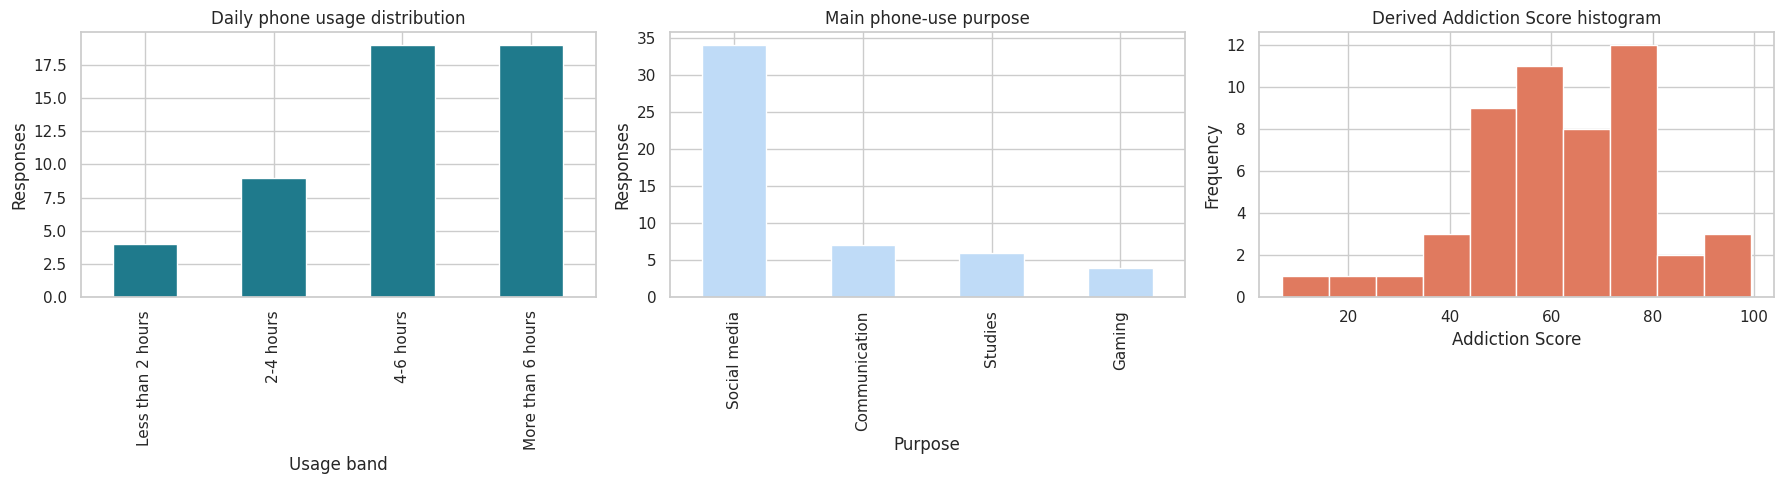

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

usage_order = ["Less than 2 hours", "2-4 hours", "4-6 hours", "More than 6 hours"]
cleaned_df["daily_hours"].value_counts().reindex(usage_order).plot(
    kind="bar", ax=axes[0], color="#1f7a8c"
)
axes[0].set_title("Daily phone usage distribution")
axes[0].set_xlabel("Usage band")
axes[0].set_ylabel("Responses")

cleaned_df["main_purpose"].value_counts().plot(kind="bar", ax=axes[1], color="#bfdbf7")
axes[1].set_title("Main phone-use purpose")
axes[1].set_xlabel("Purpose")
axes[1].set_ylabel("Responses")

cleaned_df["addiction_score"].dropna().plot(kind="hist", bins=10, ax=axes[2], color="#e07a5f")
axes[2].set_title("Derived Addiction Score histogram")
axes[2].set_xlabel("Addiction Score")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 6. Probability Concepts from Real Survey Data

**Concept**  
Probability is interpreted as relative frequency in the survey sample.

**Formula**

\[
P(A) = \frac{n(A)}{n}
\qquad
P(B \mid A) = \frac{n(A \cap B)}{n(A)}
\]

In [6]:
probabilities = probability_summary(cleaned_df)
display(pd.Series(probabilities).to_frame(name="probability"))

,probability
heavy_use_probability,0.3725
sleep_affected_probability,0.3878
study_distraction_probability,0.6667
sleep_affected_given_heavy_use,0.4737


## 7. Random Variable Coding

**Concept**  
We convert survey responses into numeric random variables so that expected value and variance can be computed.

**Formula**  
For coded daily usage hours:

\[
X \in \{1,2,3,4\}
\]

In [7]:
daily_hours_distribution = build_frequency_table(cleaned_df["daily_hours_code"])
display(daily_hours_distribution)

,value,count,probability,percentage
0,1,4,0.078431,7.843137
1,2,9,0.176471,17.647059
2,3,19,0.372549,37.254902
3,4,19,0.372549,37.254902


## 8. Expected Value and Variance

**Concept**  
Expected value is the weighted average of a discrete random variable. Variance measures spread around that expected value.

**Formula**

\[
E(X) = \sum xP(X=x)
\qquad
Var(X) = \sum (x - E(X))^2 P(X=x)
\]

In [8]:
daily_hours_random_variable = random_variable_summary(cleaned_df["daily_hours_code"])
display(daily_hours_random_variable["distribution"])
display(
    pd.Series(
        {
            "Expected value": daily_hours_random_variable["expected_value"],
            "Variance": daily_hours_random_variable["variance"],
        }
    ).to_frame(name="value")
)

,value,count,probability,percentage
0,1,4,0.078431,7.843137
1,2,9,0.176471,17.647059
2,3,19,0.372549,37.254902
3,4,19,0.372549,37.254902


,value
Expected value,3.0392
Variance,0.8612


## 9. Sampling Concepts

**Concept**  
A sample is a subset drawn from the observed survey data. Sampling shows why small groups can differ from the overall dataset mean.

**Formula**

\[
\bar{X}_{sample} = \frac{\sum x_i}{n_{sample}}
\]

In [9]:
sample = cleaned_df["addiction_score"].dropna().sample(n=8, random_state=42)
display(sample.to_frame(name="sample_score"))
print("Sample mean:", round(sample.mean(), 4))
print("Population mean:", round(cleaned_df["addiction_score"].dropna().mean(), 4))

,sample_score
44,53.2
41,50.7
47,59.1
12,55.5
24,42.1
32,57.8
17,71.3
33,63.3


Sample mean: 56.625
Population mean: 62.249


## 10. Central Limit Theorem Simulation

**Concept**  
The Central Limit Theorem states that the distribution of sample means becomes more normal as repeated samples are drawn.

**Formula**

\[
\bar{X} \approx N\left(\mu, \frac{\sigma^2}{n}\right)
\]

,bin_start,bin_end,count
0,42.412500,45.878125,2
1,45.878125,49.343750,8
2,49.343750,52.809375,24
3,52.809375,56.275000,49
4,56.275000,59.740625,90


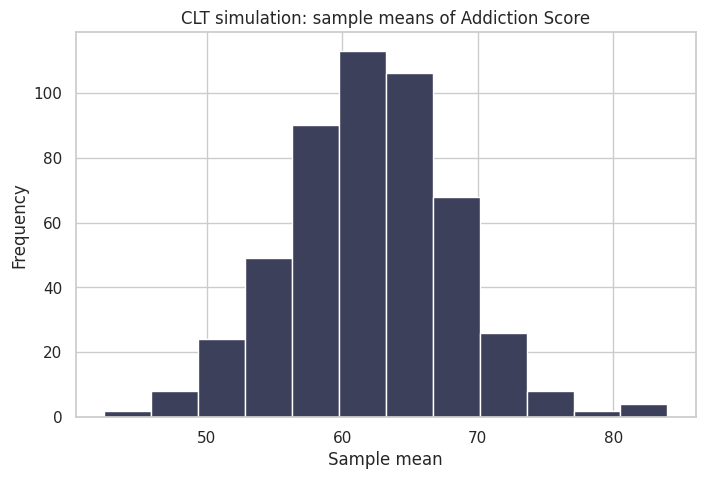

In [10]:
sample_means = clt_simulation(cleaned_df["addiction_score"], sample_size=8, simulations=500, random_state=42)
histogram = histogram_frame(sample_means, bins=12)
display(histogram.head())

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=12, color="#3d405b", edgecolor="white")
plt.title("CLT simulation: sample means of Addiction Score")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.show()

## 11. Linear Regression as Advanced Extension

**Concept**  
Linear regression predicts the continuous Addiction Score from selected phone-behavior features.

**Formula**

\[
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
\]

In [11]:
linear_metrics = pd.Series(model_results["linear"]["metrics"])
linear_coefficients = pd.DataFrame(model_results["linear"]["coefficient_items"])
display(linear_metrics.to_frame(name="value"))
display(linear_coefficients)

,value
sample_size,51.000000
train_size,38.000000
test_size,13.000000
intercept,-21.699244
r2,0.923715
mae,4.129756
rmse,4.840917


,key,python_key,label,value
0,dailyHours,daily_hours,Daily phone usage,5.489640
1,checkingFrequency,checking_frequency,Checking frequency,5.359185
2,beforeSleep,before_sleep,Before-sleep use,5.686827
3,anxiousWithoutPhone,anxious_without_phone,Anxiety without phone,5.531434
4,studyDistraction,study_distraction,Study distraction,5.553173
5,wasteTime,waste_time,Feels like wasted time,3.933878
6,socialMediaIntensity,social_media_intensity,Social media intensity,0.975851
7,reductionIntent,reduction_intent,Reduction intent,2.148836


## 12. Logistic Regression as Advanced Extension

**Concept**  
Logistic regression predicts the probability that a student's pattern falls into the elevated addiction-risk class.

**Formula**

\[
P(Y=1) = \frac{1}{1 + e^{-z}}
\qquad
z = \beta_0 + \beta_1x_1 + \cdots + \beta_nx_n
\]

,value
sample_size,51
train_size,38
test_size,13
accuracy,0.769231
precision,0.777778
recall,0.875
f1,0.823529
roc_auc,0.925
confusion_matrix,"[[3, 2], [1, 7]]"
intercept,-15.155123


,key,python_key,label,value
0,dailyHours,daily_hours,Daily phone usage,0.835378
1,checkingFrequency,checking_frequency,Checking frequency,0.605863
2,beforeSleep,before_sleep,Before-sleep use,1.415360
3,anxiousWithoutPhone,anxious_without_phone,Anxiety without phone,1.222479
4,studyDistraction,study_distraction,Study distraction,0.582890
5,wasteTime,waste_time,Feels like wasted time,0.353576
6,socialMediaIntensity,social_media_intensity,Social media intensity,0.304760
7,reductionIntent,reduction_intent,Reduction intent,0.956338


,Predicted 0,Predicted 1
Actual 0,3,2
Actual 1,1,7


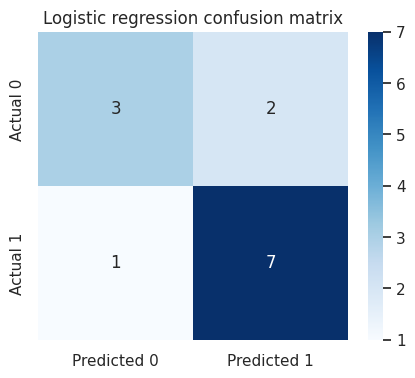

In [12]:
logistic_metrics = pd.Series(model_results["logistic"]["metrics"])
logistic_coefficients = pd.DataFrame(model_results["logistic"]["coefficient_items"])
display(logistic_metrics.to_frame(name="value"))
display(logistic_coefficients)

confusion = pd.DataFrame(
    model_results["logistic"]["metrics"]["confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)
display(confusion)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic regression confusion matrix")
plt.show()

## 13. Final Findings

**Concept**  
The final findings combine descriptive statistics, probability, sampling, and model evidence into one interpretation.

**Interpretation**  
The concluding code below prints short academically responsible findings based on the current dataset snapshot.

In [13]:
findings = [
    f"The cleaned survey dataset contains {prepared.metadata['clean_row_count']} usable rows after excluding malformed responses.",
    f"The mean derived Addiction Score is {score_stats['mean']:.2f} with standard deviation {score_stats['standard_deviation']:.2f}.",
    f"The probability of being in the highest daily-use band is {probabilities['heavy_use_probability']:.2%}.",
    f"Linear regression achieved R^2 = {model_results['linear']['metrics']['r2']:.3f} on the held-out test split.",
    f"Logistic regression achieved accuracy = {model_results['logistic']['metrics']['accuracy']:.3f} on the held-out test split.",
]

for item in findings:
    print("-", item)

- The cleaned survey dataset contains 51 usable rows after excluding malformed responses.
- The mean derived Addiction Score is 62.25 with standard deviation 17.88.
- The probability of being in the highest daily-use band is 37.25%.
- Linear regression achieved R^2 = 0.924 on the held-out test split.
- Logistic regression achieved accuracy = 0.769 on the held-out test split.
